# Initial LSDB Streaming Improvements

In this notebook showcasing the current LSDB CatalogStream implementation against an implementation (suggested by Claude Code) that initializes the Stream as a set of pre-optimized delayed tasks. Branch here: https://github.com/astronomy-commons/lsdb/tree/claude_streaming

In [2]:
import lsdb
from lsdb.streams import CatalogStream, InfiniteStream
import numpy as np
import nested_pandas as npd
import dask.dataframe as dd
from dask.distributed import Client
import time
import warnings
warnings.filterwarnings("ignore")

cat7 = lsdb.open_catalog("catalogs/catalog7/generated_catalog")
cat2 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
cat3 = lsdb.open_catalog("catalogs/catalog3/generated_catalog")
cat4 = lsdb.open_catalog("catalogs/catalog4/generated_catalog")
cat8 = lsdb.open_catalog("catalogs/catalog8/generated_catalog")

In [3]:
def report_performance(catalog, n_workers, partitions_per_chunk, memory_limit="3GB"):
    print(f"number of workers: {n_workers}")
    print(f"partitions_per_chunk (streaming): {partitions_per_chunk}")
    results = {}

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
    results["Compute/Client"] = time1 - time0

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
    results["Stream/Client"] = time1 - time0

    time0 = time.time()
    catalog.compute()
    time1 = time.time()
    results["Compute/NoClient"] = time1 - time0

    stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
    time0 = time.time()
    for chunk in stream:
        chunk
    time1 = time.time()
    results["Stream/NoClient"] = time1 - time0

    return results

def collate_performance(catalog, n_workers_list, partitions_per_chunk_list, memory_limit="3GB"):
    all_results = {}

    # NoClient doesn't depend on n_workers, so only run it once
    for partitions_per_chunk in partitions_per_chunk_list:
        #print(f"\n--- Running NoClient: partitions_per_chunk={partitions_per_chunk} ---")
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
        compute_noclient = time1 - time0

        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
        stream_noclient = time1 - time0

        all_results[(None, partitions_per_chunk)] = {
            "Compute/NoClient": compute_noclient,
            "Stream/NoClient": stream_noclient,
        }

    # Client results depend on both n_workers and partitions_per_chunk
    for n_workers in n_workers_list:
        for partitions_per_chunk in partitions_per_chunk_list:
            #print(f"\n--- Running Client: n_workers={n_workers}, partitions_per_chunk={partitions_per_chunk} ---")

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                time0 = time.time()
                catalog.compute()
                time1 = time.time()
                compute_client = time1 - time0

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
                time0 = time.time()
                for chunk in stream:
                    chunk
                time1 = time.time()
                stream_client = time1 - time0

            all_results[(n_workers, partitions_per_chunk)] = {
                "Compute/Client": compute_client,
                "Stream/Client": stream_client,
            }

    return all_results

def plot_collated_results(all_results, title=None):
    import pandas as pd
    import matplotlib.pyplot as plt

    client_rows, noclient_rows = [], []
    for (n_workers, partitions_per_chunk), metrics in all_results.items():
        row = {"partitions_per_chunk": partitions_per_chunk, **metrics}
        if n_workers is None:
            noclient_rows.append(row)
        else:
            client_rows.append({"n_workers": n_workers, **row})

    client_df = pd.DataFrame(client_rows)
    noclient_df = pd.DataFrame(noclient_rows).sort_values("partitions_per_chunk")

    n_workers_vals = sorted(client_df["n_workers"].unique())
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    if title is None:
        fig.suptitle("`open_catalog` Performance Results", fontsize=14, fontweight="bold")
    else:
        fig.suptitle(title, fontsize=14, fontweight="bold")

    # --- Client plot ---
    ax = axes[0]
    ax.set_title("Distributed Client")
    for i, n_workers in enumerate(n_workers_vals):
        color = prop_cycle[i % len(prop_cycle)]
        subset = client_df[client_df["n_workers"] == n_workers].sort_values("partitions_per_chunk")
        ax.plot(subset["partitions_per_chunk"], subset["Stream/Client"], marker="o",
                color=color, label=f"Stream ({n_workers} workers)")
        compute_mean = subset["Compute/Client"].mean()
        ax.axhline(compute_mean, color=color, linestyle="--",
                   label=f"Compute mean ({n_workers} workers)")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- NoClient plot ---
    ax = axes[1]
    ax.set_title("Local Cluster (No Client)")
    color = prop_cycle[0]
    ax.plot(noclient_df["partitions_per_chunk"], noclient_df["Stream/NoClient"], marker="o",
            color=color, label="Stream")
    compute_mean = noclient_df["Compute/NoClient"].mean()
    ax.axhline(compute_mean, color=color, linestyle="--", label="Compute mean")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

In [ ]:
# run collations -- current
xmatch = cat3.crossmatch(cat4, suffixes=("_l","_r"))
results_oc_current = collate_performance(cat7, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
results_xmatch_current = collate_performance(xmatch, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])

In [ ]:
# run collations -- delayed
xmatch = cat3.crossmatch(cat4, suffixes=("_l","_r"))
results_oc_delayed = collate_performance(cat7, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
results_xmatch_delayed = collate_performance(xmatch, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])

## Opening a Catalog - Current Streaming Implementation

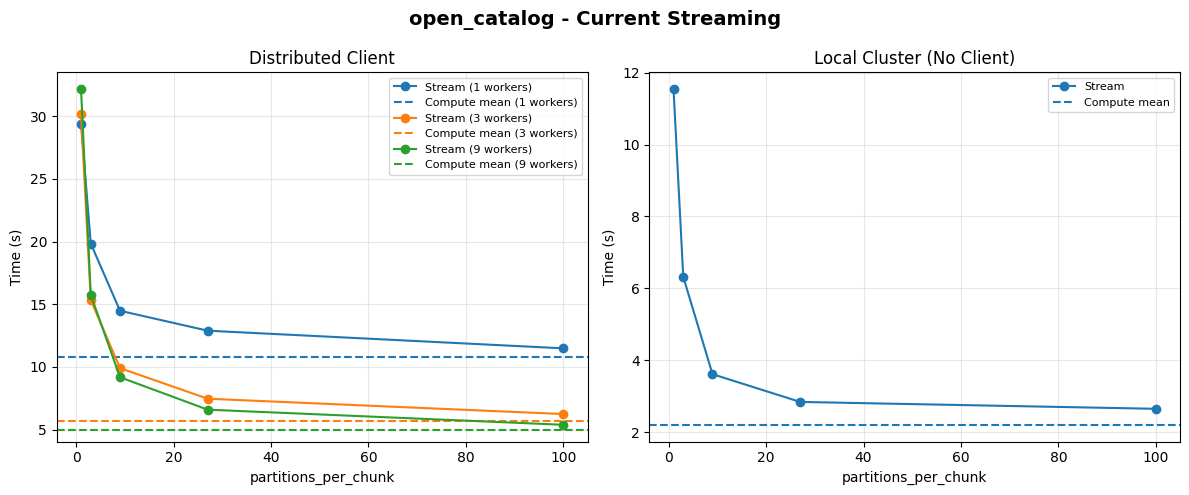

In [4]:
#results = collate_performance(cat7, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
fig = plot_collated_results(results_oc_current, "open_catalog - Current Streaming")
#cat7

## Opening a Catalog - Delayed Streaming Implementation

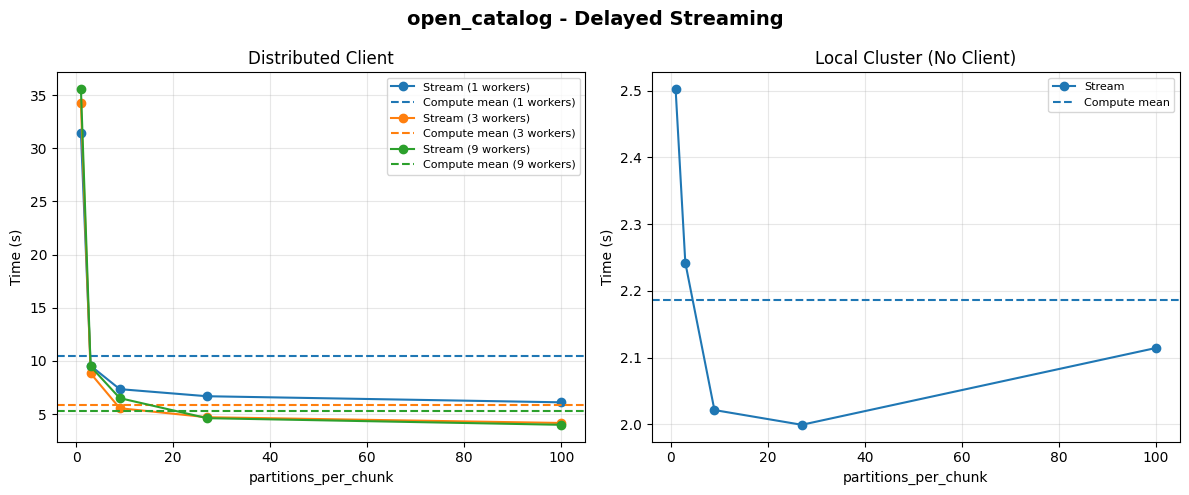

In [5]:
fig = plot_collated_results(results_oc_delayed, "open_catalog - Delayed Streaming")

## Basic Crossmatch - Current Streaming Implementation

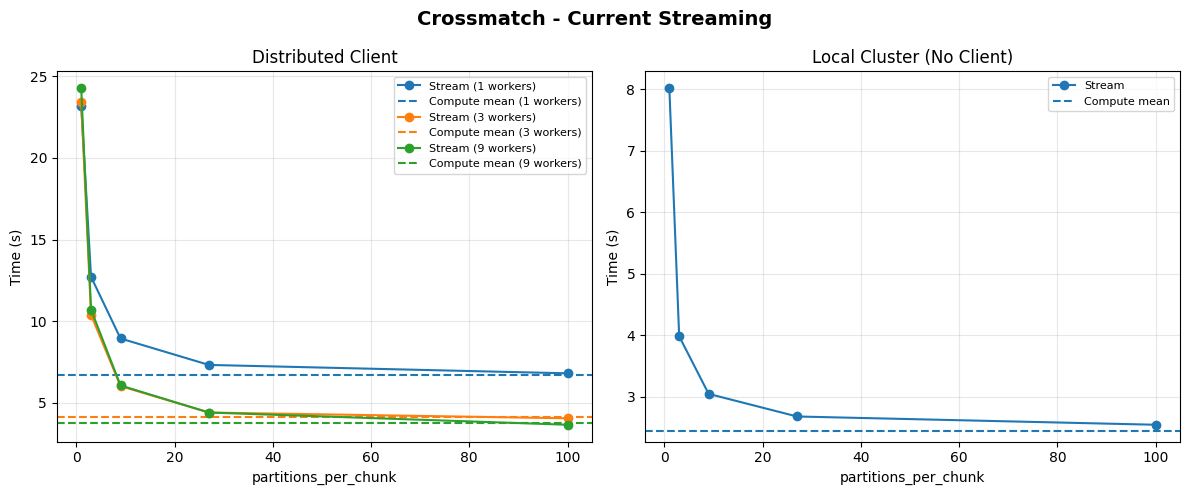

In [5]:
#xmatch = cat3.crossmatch(cat4, suffixes=("_l","_r"))
#results_oc_current = collate_performance(xmatch, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
fig = plot_collated_results(results_xmatch_current, "Crossmatch - Current Streaming")
#xmatch

## Basic Crossmatch - Delayed Streaming Implementation

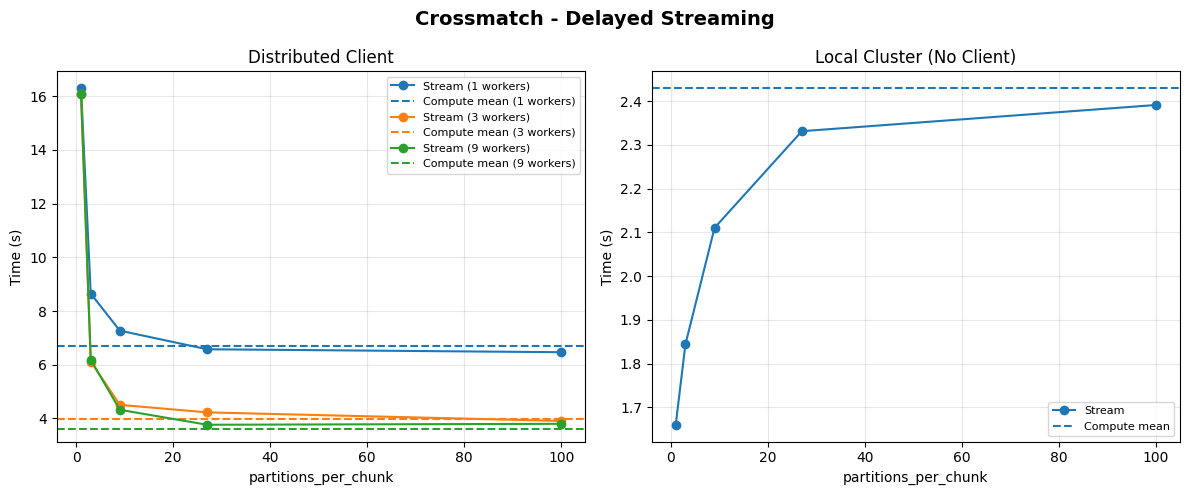

In [6]:
fig = plot_collated_results(results_xmatch_delayed, "Crossmatch - Delayed Streaming")

## Current Takeaways:

* The delayed implementation does optimization once up front, and avoids a lot of overhead we're currently doing by just calling compute(), as we can see in the local_cluster case
* For a distributed cluster, we have to deal with the additional overhead of the distributer scheduler round trip (submit task → scheduler dispatches → worker computes → result serialized back to client), so for many low partitions_per_chunk we'll be hit by this
    * However, if this is a fixed cost, maybe it's not so bad for "real" workflows. Will look into this more
    * We may want to discourage the use of a distributed client for this in some cases
    * Potentially can explore how to get around this, maybe doing more prefetching, but goal of streaming is to not materialize too much memory at any given time so this should be done thoughtfully (or optionally)
* Haven't looked at memory too much, but initial findings suggest this isn't introducing any memory issues. We moved away from delayed in crossmatching, but I think the issue there was to_delayed/from_delayed loops, whereas here we are just doing to_delayed and submitting to the scheduler.